## HR estimation using Peak detection
- Use different chunk size and sliding window size to estimate HR
- Use peak detection method
- take mean of all chunks for each subject (mean HR)

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from collections import defaultdict

CONFIG

In [4]:
FPS = 30                         # Sampling rate (frames per second)
WINDOW_SIZES_SEC = [3, 4, 5]    # Window sizes to test in seconds
OVERLAP_RATIO = 0.5              # 50% overlap for overlapping windows
GT_DIR = "GT_ref/"               # Directory with .npy files

# Peak detection parameters (tuned for BVP signal)
PEAK_PROMINENCE = 0.3
PEAK_DISTANCE_SEC = 0.3          # Min distance between peaks in seconds

STEP 1: LOAD & GROUP BY SUBJECT

In [5]:
# =============================================================================
# STEP 1: LOAD & GROUP BY SUBJECT
# =============================================================================
def load_gt_npy_files(gt_dir):
    """
    Load all .npy files and group by subject ID.
    
    Assumes filename format: {subject_id}_label{n}.npy
    e.g. 101_label0.npy, 101_label1.npy, ...
    
    Returns:
        dict: {subject_id: [array_chunk0, array_chunk1, ...]}
    """
    gt_files = sorted(glob.glob(os.path.join(gt_dir, '*_label*.npy')))
    
    if not gt_files:
        print(f"No label files found in {gt_dir}")
        return {}

    subject_chunks = defaultdict(list)
    
    for gt_file in gt_files:
        filename = os.path.basename(gt_file).split('.')[0]  # e.g. '101_label4'
        subject_id = filename.split('_')[0]                 # e.g. '101'
        chunk = np.load(gt_file)
        subject_chunks[subject_id].append(chunk)
    
    print(f"Loaded {len(gt_files)} files across {len(subject_chunks)} subjects")
    for subj, chunks in subject_chunks.items():
        print(f"  Subject {subj}: {len(chunks)} chunks × {chunks[0].shape[0]} samples "
              f"= {len(chunks) * chunks[0].shape[0]} total samples "
              f"≈ {len(chunks) * chunks[0].shape[0] / FPS:.1f}s")
    
    return dict(subject_chunks)

# =============================================================================
# STEP 2: CONCATENATE SUBJECT SIGNALS
# =============================================================================
def concatenate_subject_signal(subject_chunks):
    """
    Concatenate all chunks for each subject into one continuous signal.
    
    Returns:
        dict: {subject_id: np.array of shape (total_samples,)}
    """
    subject_signals = {}
    for subject_id, chunks in subject_chunks.items():
        signal = np.concatenate(chunks)
        subject_signals[subject_id] = signal
    return subject_signals

# =============================================================================
# STEP 3: SPLIT SIGNAL INTO EQUAL CHUNKS
# =============================================================================
def split_into_chunks(signal, chunk_size):
    """
    Split a continuous signal into equal-sized non-overlapping chunks.
    Discards any remaining samples if signal length is not perfectly divisible.

    Args:
        signal:     1D numpy array (full concatenated subject signal)
        chunk_size: number of samples per chunk (e.g. 160, 320, 480)

    Returns:
        list of np.arrays, each of length chunk_size
        (remainder samples discarded with a warning)
    """
    n_samples   = len(signal)
    n_chunks    = n_samples // chunk_size
    remainder   = n_samples % chunk_size

    if remainder != 0:
        print(f"  ⚠️  Signal length {n_samples} not divisible by chunk_size {chunk_size}. "
              f"Discarding last {remainder} samples — using {n_chunks} complete chunks.")

    chunks = [signal[i * chunk_size : (i + 1) * chunk_size] for i in range(n_chunks)]
    return chunks


### HR estimation

In [13]:
# =============================================================================
# STEP 3A: NON-OVERLAPPING SLIDING WINDOW
# =============================================================================
def sliding_window_non_overlapping(signal, window_size_sec, fps=FPS):
    """
    Split signal into non-overlapping windows of fixed size.
    Step = window_size (no overlap).
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        fps: sampling rate
    
    Returns:
        list of np.arrays, each of length window_size_samples
    """
    window_size = int(window_size_sec * fps)  # samples
    n_samples = len(signal)
    windows = []
    
    start = 0
    while start + window_size <= n_samples:
        window = signal[start : start + window_size]
        windows.append(window)
        start += window_size  # step = full window (no overlap)
    
    print(f"  [Non-overlapping] window={window_size_sec}s ({window_size} samples): "
          f"{len(windows)} complete windows "
          f"(discarded last {n_samples - start} samples)")
    
    return windows


# =============================================================================
# STEP 3B: OVERLAPPING SLIDING WINDOW
# =============================================================================
def sliding_window_overlapping(signal, window_size_sec, overlap_ratio=OVERLAP_RATIO, fps=FPS):
    """
    Split signal into overlapping windows.
    Step = window_size * (1 - overlap_ratio).
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        overlap_ratio: fraction of overlap (0.5 = 50%)
        fps: sampling rate
    
    Returns:
        list of np.arrays, each of length window_size_samples
    """
    window_size = int(window_size_sec * fps)               # samples
    step_size   = int(window_size * (1 - overlap_ratio))   # e.g. 50% overlap → step = half window
    n_samples   = len(signal)
    windows     = []
    
    start = 0
    while start + window_size <= n_samples:
        window = signal[start : start + window_size]
        windows.append(window)
        start += step_size
    
    print(f"  [Overlapping {int(overlap_ratio*100)}%] window={window_size_sec}s ({window_size} samples), "
          f"step={step_size} samples: {len(windows)} windows")
    
    return windows


# =============================================================================
# STEP 4: PEAK DETECTION → HR PER WINDOW
# =============================================================================
def detect_hr_from_window(window, fps=FPS,
                           prominence=PEAK_PROMINENCE,
                           min_distance_sec=PEAK_DISTANCE_SEC):
    """
    Detect peaks in a BVP window and compute HR in bpm.
    
    Args:
        window: 1D numpy array (single window of BVP signal)
        fps: sampling rate
        prominence: minimum peak prominence
        min_distance_sec: minimum distance between peaks in seconds
    
    Returns:
        float or None: HR in bpm, or None if insufficient peaks
    """
    prominence = 0.2 * np.std(window) # Adaptive thresholds based on signal variability
    min_distance_samples = int(fps * min_distance_sec)
    
    peaks, _ = find_peaks(window,
                           prominence=prominence,
                           distance=min_distance_samples)
    
    if len(peaks) < 2:
        return None  # Not enough peaks to compute HR
    
    # Inter-peak intervals → HR
    peak_intervals_sec = np.diff(peaks) / fps  # seconds between peaks
    hr_per_interval    = 60.0 / peak_intervals_sec  # bpm

    mean_interval = np.mean(peak_intervals_sec) #2nd option
    HR = 60 / mean_interval
    return HR
    # return hr_per_interval.mean()


# =============================================================================
# STEP 5: FULL HR ESTIMATION PIPELINE
# =============================================================================
def estimate_hr(signal, window_size_sec, mode='non_overlapping',
                overlap_ratio=OVERLAP_RATIO, fps=FPS):
    """
    Full pipeline: signal → windows → HR per window → mean HR.
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        mode: 'non_overlapping' or 'overlapping'
        overlap_ratio: only used if mode='overlapping'
        fps: sampling rate
    
    Returns:
        dict with:
            hr_per_window: list of HR values (bpm) per window
            mean_hr: mean HR across all valid windows
            std_hr: std of HR across all valid windows
            n_windows_total: total windows created
            n_windows_valid: windows with enough peaks
    """
    # Get windows
    if mode == 'non_overlapping':
        windows = sliding_window_non_overlapping(signal, window_size_sec, fps)
    elif mode == 'overlapping':
        windows = sliding_window_overlapping(signal, window_size_sec, overlap_ratio, fps)
    else:
        raise ValueError(f"mode must be 'non_overlapping' or 'overlapping', got '{mode}'")
    
    # HR per window
    hr_per_window = []
    for w in windows:
        hr = detect_hr_from_window(w, fps)
        if hr is not None:
            hr_per_window.append(hr)
    
    n_valid = len(hr_per_window)
    
    if n_valid == 0:
        print(f"  ⚠️  No valid windows found for window_size={window_size_sec}s")
        return {
            "hr_per_window": [],
            "mean_hr": None,
            "std_hr": None,
            "n_windows_total": len(windows),
            "n_windows_valid": 0
        }
    
    hr_array = np.array(hr_per_window)
    
    return {
        "hr_per_window": hr_per_window,
        "mean_hr": float(np.mean(hr_array)),
        "std_hr":  float(np.std(hr_array)),
        "n_windows_total": len(windows),
        "n_windows_valid": n_valid
    }

In [14]:
# =============================================================================
def estimate_hr_chunk_mean(signal, chunk_size, window_size_sec,
                            mode='non_overlapping'):
    """
    For a given chunk_size:
        1. Split signal into equal chunks
        2. Run sliding-window HR estimation on each chunk
        3. Return mean HR across all valid chunks

    Args:
        signal:          1D numpy array (full subject signal)
        chunk_size:      samples per chunk (160, 320, 480, ...)
        window_size_sec: sliding window size in seconds
        mode:            'non_overlapping' or 'overlapping'

    Returns:
        dict with:
            chunk_hrs:       list of per-chunk mean HR (one per chunk)
            mean_hr:         mean of chunk_hrs
            std_hr:          std of chunk_hrs
            n_chunks_total:  total chunks created
            n_chunks_valid:  chunks that produced a valid HR (≥2 peaks)
            chunk_size:      samples per chunk (for reference)
            chunk_size_sec:  seconds per chunk
    """
    chunks = split_into_chunks(signal, chunk_size)
    n_chunks_total = len(chunks)

    chunk_hrs = []
    for i, chunk in enumerate(chunks):
        res = estimate_hr(chunk, window_size_sec, mode=mode)
        # print(f"{'*'*65}")
        # print(f"  Chunk {i+1}/{n_chunks_total}: "
        #       f"HR {res}")
        # print(f"{'*'*65}")
        if res['mean_hr'] is not None:
            chunk_hrs.append(res['mean_hr'])
        else:
            print(f"    ⚠️  Chunk {i+1}: no valid HR (insufficient peaks) — skipped")

    n_valid = len(chunk_hrs)

    if n_valid == 0:
        return {
            "chunk_hrs":      [],
            "mean_hr":        None,
            "std_hr":         None,
            "n_chunks_total": n_chunks_total,
            "n_chunks_valid": 0,
            "chunk_size":     chunk_size,
            "chunk_size_sec": round(chunk_size / FPS, 1),
        }

    return {
        "chunk_hrs":      chunk_hrs,
        "mean_hr":        float(np.mean(chunk_hrs)),
        "std_hr":         float(np.std(chunk_hrs)),
        "n_chunks_total": n_chunks_total,
        "n_chunks_valid": n_valid,
        "chunk_size":     chunk_size,
        "chunk_size_sec": round(chunk_size / FPS, 1),
    }

In [15]:
# =============================================================================
# STEP 6: RUN ON ALL SUBJECTS × ALL WINDOW SIZES
# =============================================================================
def run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC):
    """
    Run HR estimation for all subjects, all window sizes, both modes.
    
    Returns:
        dict: results[subject_id][window_size][mode] = estimate_hr output
    """
    results = {}
    
    for subject_id, signal in subject_signals.items():
        print(f"\n{'='*60}")
        print(f"Subject: {subject_id} | Signal length: {len(signal)} samples "
              f"≈ {len(signal)/FPS:.1f}s")
        print(f"{'='*60}")
        
        results[subject_id] = {}
        
        for ws in window_sizes_sec:
            results[subject_id][ws] = {}
            print(f"\n  Window size: {ws}s")
            
            for mode in ['non_overlapping', 'overlapping']:
                res = estimate_hr(signal, ws, mode=mode)
                results[subject_id][ws][mode] = res
                
                if res['mean_hr'] is not None:
                    print(f"    [{mode:>17}] "
                          f"Mean HR = {res['mean_hr']:5.1f} bpm | "
                          f"Std = {res['std_hr']:4.1f} | "
                          f"Valid windows = {res['n_windows_valid']}/{res['n_windows_total']}")
    
    return results

def run_chunk_analysis(subject_signals,
                        chunk_sizes=(160, 320, 480),
                        window_sizes_sec=(3, 4, 5)):
    """
    Run chunk-level HR estimation for all subjects,
    all chunk sizes, all window sizes, both modes.

    Returns:
        dict: results[subject_id][chunk_size][window_size][mode]
    """
    results = {}

    for subject_id, signal in subject_signals.items():
        results[subject_id] = {}
        print(f"\n{'='*65}")
        print(f"Subject: {subject_id} | Full signal: {len(signal)} samples "
              f"({len(signal)/FPS:.1f}s)")
        print(f"{'='*65}")

        for chunk_size in chunk_sizes:
            n_chunks = len(signal) // chunk_size
            print(f"\n  Chunk size: {chunk_size} samples "
                  f"({chunk_size/FPS:.1f}s) → {n_chunks} chunks")

            results[subject_id][chunk_size] = {}

            for ws in window_sizes_sec:
                results[subject_id][chunk_size][ws] = {}

                for mode in ['non_overlapping', 'overlapping']:
                    res = estimate_hr_chunk_mean(signal, chunk_size, ws, mode)
                    results[subject_id][chunk_size][ws][mode] = res
                    # print(f"{'-'*65}")
                    # print(f"HR for Chunk {chunk_size} samples, Window {ws}s, Mode {mode}: "
                    #       f"Mean HR = {res['mean_hr'] if res['mean_hr'] is not None else 'N/A'} bpm, "
                    #       f"Std = {res['std_hr'] if res['std_hr'] is not None else 'N/A'}, "
                    #       f"Valid chunks = {res['n_chunks_valid']}/{res['n_chunks_total']}")
                    # print(f"{'-'*65}")

                    mean_str = f"{res['mean_hr']:.1f}" if res['mean_hr'] is not None else "N/A"
                    std_str  = f"{res['std_hr']:.1f}"  if res['std_hr']  is not None else "N/A"

                    print(f"    [chunk={chunk_size:>3}, win={ws}s, {mode:>15}] "
                        f"Mean HR = {mean_str:>6} bpm | "
                        f"Std = {std_str:>5} | "
                        f"Valid chunks = {res['n_chunks_valid']}/{res['n_chunks_total']}")

    return results

In [16]:
def export_chunk_results_to_csv(results, output_path="hr_chunk_results.csv"):
    """
    Flatten nested results into a tidy DataFrame.

    Columns:
        subject, chunk_size, chunk_size_sec, window_size_sec, mode,
        mean_hr, std_hr, n_chunks_valid, n_chunks_total
    """
    rows = []

    for subject_id, chunk_dict in results.items():
        for chunk_size, window_dict in chunk_dict.items():
            for ws, mode_dict in window_dict.items():
                for mode, res in mode_dict.items():
                    rows.append({
                        "subject":        subject_id,
                        "chunk_size":     chunk_size,
                        "chunk_size_sec": res["chunk_size_sec"],
                        "window_size_sec": ws,
                        "mode":           mode,
                        "mean_hr":        res["mean_hr"],
                        "std_hr":         res["std_hr"],
                        # "n_chunks_valid": res["n_chunks_valid"],
                        # "n_chunks_total": res["n_chunks_total"],
                    })

    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)
    print(f"\n✅ Results exported to: {output_path}")
    print(f"   Shape: {df.shape} | Subjects: {df['subject'].nunique()}")

    return df

In [17]:
FPS = 30                         # Sampling rate (frames per second)
WINDOW_SIZES_SEC = [3, 4, 5]    # Window sizes to test in seconds
OVERLAP_RATIO = 0.5              # 50% overlap for overlapping windows
GT_DIR = "GT_ref/"               # Directory with .npy files

# Peak detection parameters (tuned for BVP signal)
PEAK_PROMINENCE = 0.3
PEAK_DISTANCE_SEC = 0.3          # Min distance between peaks in seconds

In [18]:
GT_DIR = "/home/muhammadu/pre_proc_datasets/PURE_intra/PURE_SizeW128_SizeH128_ClipLength160_DataTypeStandardized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len30_Median_face_boxFalse"

subject_chunks  = load_gt_npy_files(GT_DIR)
subject_signals = concatenate_subject_signal(subject_chunks)

CHUNK_SIZES  = [160]#[160, 320, 480]   # samples → 5.3s, 10.7s, 16.0s
WINDOW_SIZES = [3,4,5]#, 4, 5]         # seconds

# Run analysis
chunk_results = run_chunk_analysis(subject_signals,
                                    chunk_sizes=CHUNK_SIZES,
                                    window_sizes_sec=WINDOW_SIZES)

df_chunks = export_chunk_results_to_csv(chunk_results, "hr_chunk_160_window_3-4-5_results.csv")

Loaded 750 files across 59 subjects
  Subject 1001: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1002: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1003: 14 chunks × 160 samples = 2240 total samples ≈ 74.7s
  Subject 1004: 14 chunks × 160 samples = 2240 total samples ≈ 74.7s
  Subject 1005: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1006: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 101: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 102: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 103: 15 chunks × 160 samples = 2400 total samples ≈ 80.0s
  Subject 104: 15 chunks × 160 samples = 2400 total samples ≈ 80.0s
  Subject 105: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 106: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 201: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 202: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subj

In [26]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_mean_hr_by_subject(df):
    """
    Plot mean HR for each subject comparing overlapping vs non-overlapping.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        subject, mode, mean_hr
    """

    # Create pivot table
    plot_df = df.pivot(
        index="subject",
        columns="mode",
        values="mean_hr"
    )

    # Sort subjects numerically
    plot_df = plot_df.sort_index()

    # Plot
    ax = plot_df.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8
    )

    ax.set_xlabel("Subject ID")
    ax.set_ylabel("Mean HR (bpm)")
    ax.set_title("Mean Heart Rate by Subject")
    ax.legend(title="Mode")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

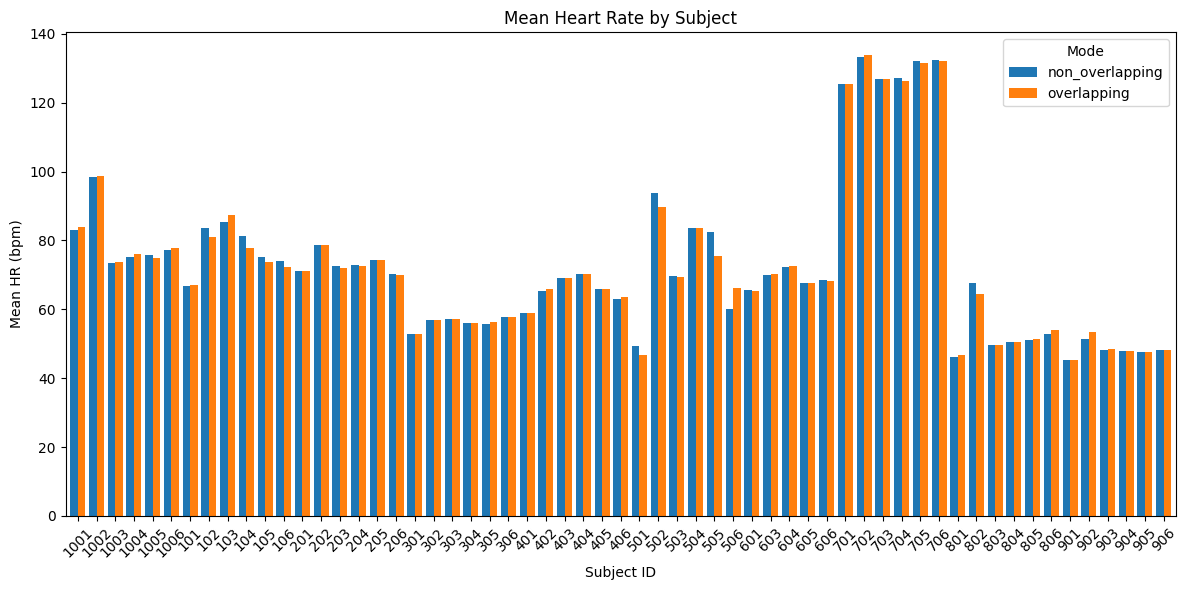

In [27]:
plot_mean_hr_by_subject(df_chunks)

In [40]:
import matplotlib.pyplot as plt


def plot_mean_hr_by_subject_line(df):
    plot_df = df.pivot(
        index="subject",
        columns="mode",
        values="mean_hr"
    ).sort_index()

    plt.figure(figsize=(18, 6))

    if "non_overlapping" in plot_df.columns:
        plt.plot(
            plot_df.index,
            plot_df["non_overlapping"],
            marker="o",
            linewidth=2,
            label="Non-overlapping"
        )

    if "overlapping" in plot_df.columns:
        plt.plot(
            plot_df.index,
            plot_df["overlapping"],
            marker="s",
            linewidth=2,
            label="Overlapping"
        )
    chunk_size = df["chunk_size"].iloc[0]
    window_size = df["window_size_sec"].iloc[0]
    plt.xlabel("Subject ID")
    plt.ylabel("Mean HR (bpm)")
    plt.title(
    f"Mean Heart Rate by Subject\nChunk Size: {df['chunk_size'].iloc[0]} ({df['chunk_size_sec'].iloc[0]} s), Window Size: {df['window_size_sec'].iloc[0]} s"
)
    plt.xticks(rotation=90) 
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

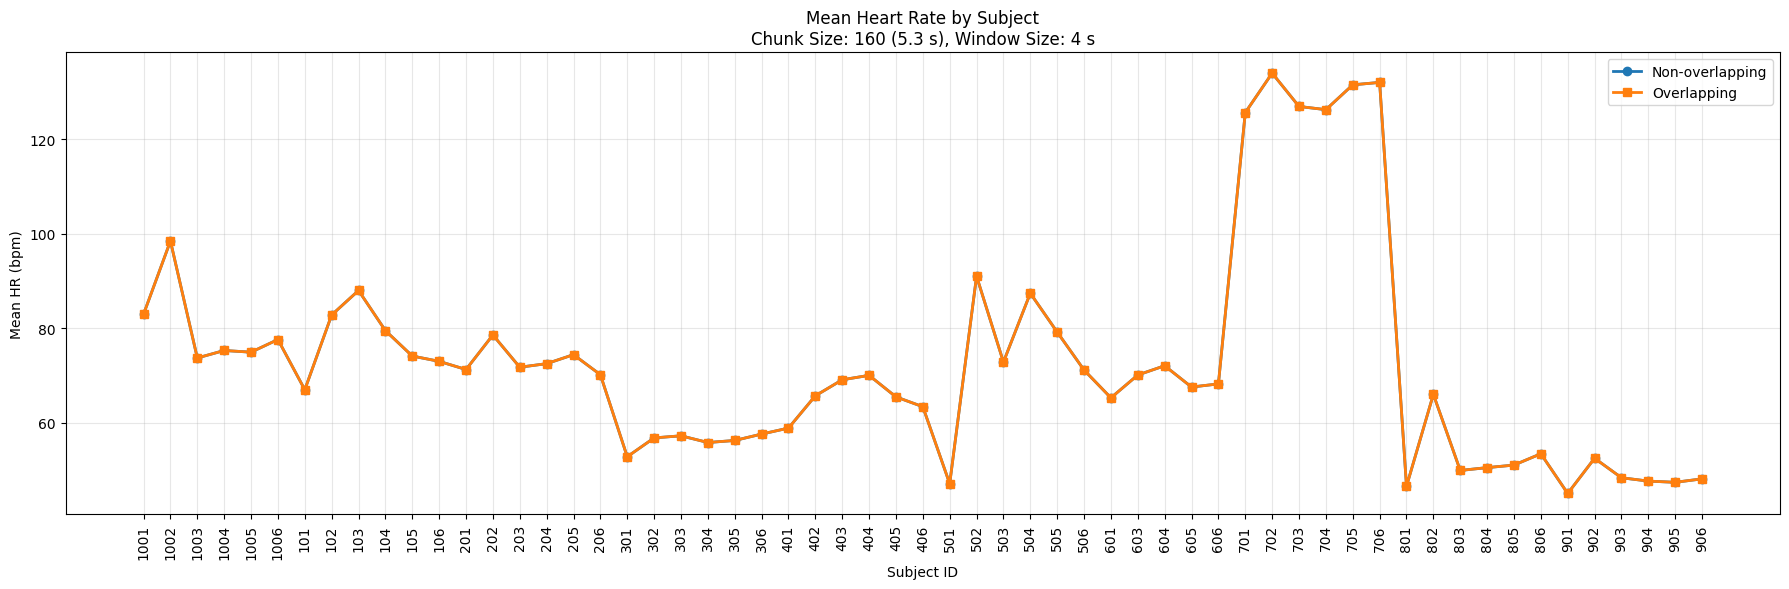

In [45]:
plot_mean_hr_by_subject_line(df_chunks)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mean_hr_by_subject(df):
    window_sizes = sorted(df["window_size_sec"].unique())

    fig, axes = plt.subplots(
        len(window_sizes), 1,
        figsize=(14, 4 * len(window_sizes)),
        sharex=True
    )

    # If only one window size, make axes iterable
    if len(window_sizes) == 1:
        axes = [axes]

    for ax, ws in zip(axes, window_sizes):

        df_ws = df[df["window_size_sec"] == ws]

        plot_df = (
            df_ws.pivot(
                index="subject",
                columns="mode",
                values="mean_hr"
            )
            .sort_index()
        )

        if "non_overlapping" in plot_df.columns:
            ax.plot(
                plot_df.index,
                plot_df["non_overlapping"],
                marker="o",
                label="Non-overlapping"
            )

        if "overlapping" in plot_df.columns:
            ax.plot(
                plot_df.index,
                plot_df["overlapping"],
                marker="s",
                label="Overlapping"
            )

        ax.set_title(f"Window Size = {ws} s")
        ax.set_ylabel("Mean HR (bpm)")
        ax.grid(alpha=0.3)
        ax.legend()
    # main title
    plt.suptitle(f"Mean Heart Rate by Subject_Chunk Size: {df['chunk_size'].iloc[0]}", fontsize=16, y=1.02)
    axes[-1].set_xlabel("Subject ID")
    axes[-1].tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

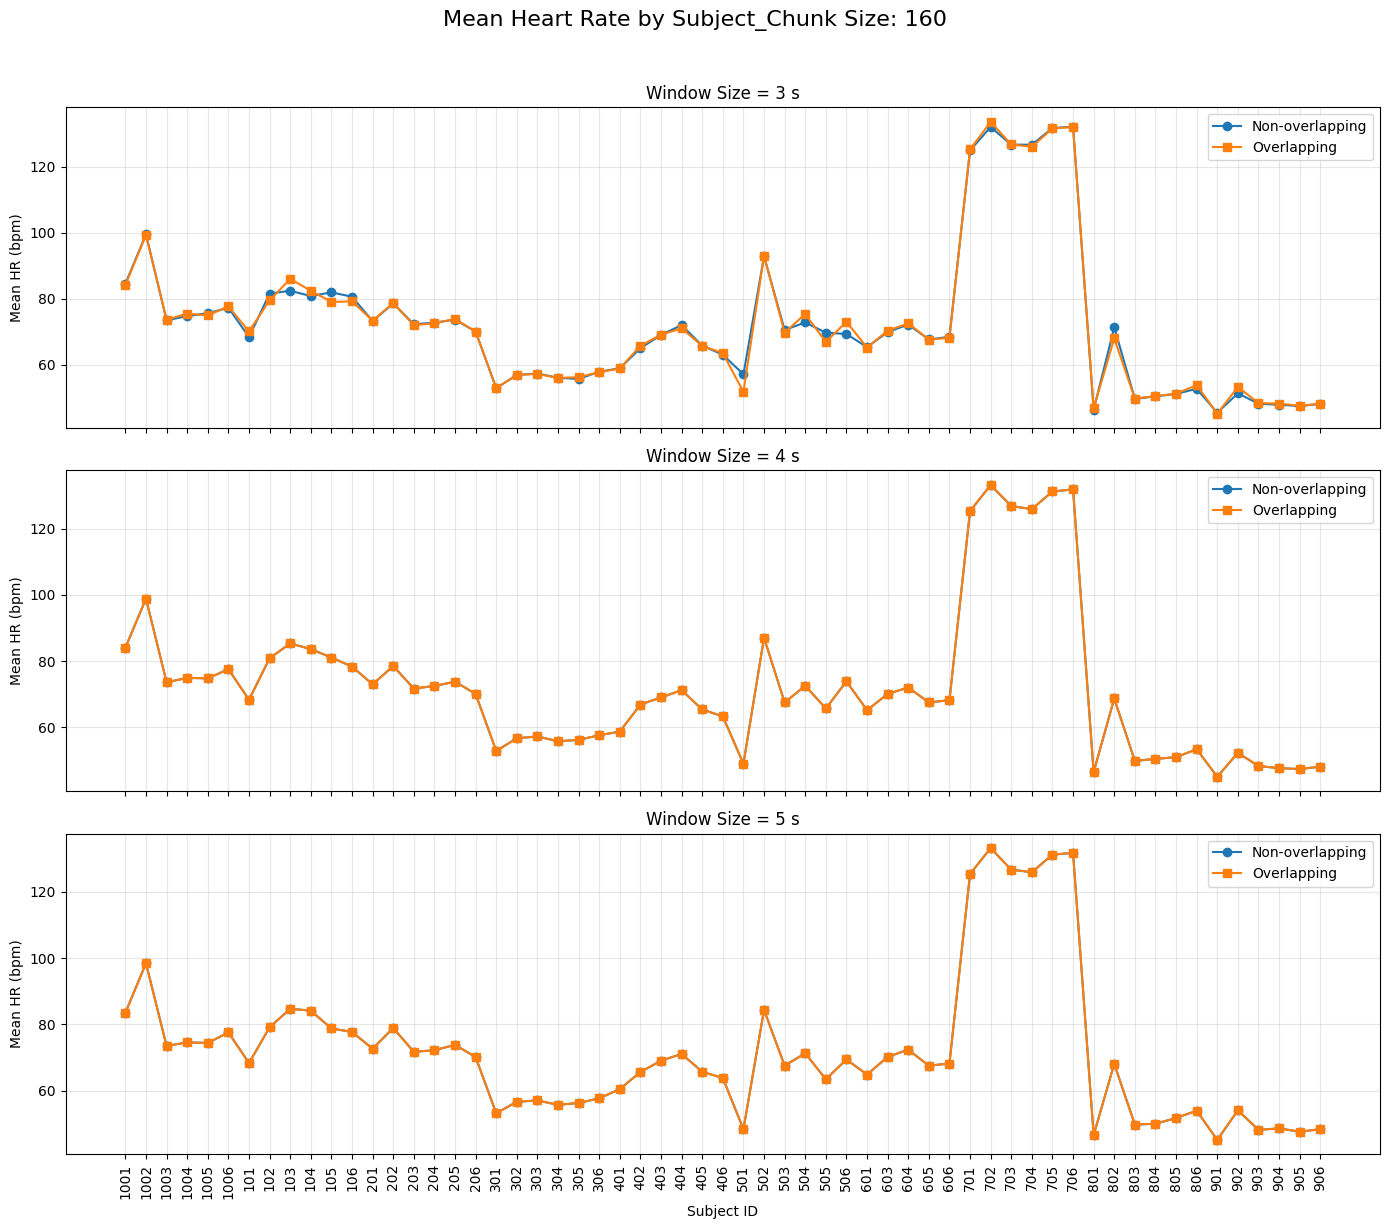

In [20]:
plot_mean_hr_by_subject(df_chunks)